# Unzip the data

In [1]:
import zipfile

with zipfile.ZipFile("../data/raw/ml-latest-small.zip", "r") as file:
    file.extractall("../data/raw/")

# Read the dataset files

In [2]:
import pandas as pd

In [73]:
movies = pd.read_csv("../data/raw/ml-latest-small/movies.csv")

movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [3]:
ratings = pd.read_csv("../data/raw/ml-latest-small/ratings.csv")

ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [5]:
tags = pd.read_csv("../data/raw/ml-latest-small/tags.csv")

tags.head()

,userId,movieId,tag,timestamp
0,2,60756,funny,1445714994
1,2,60756,Highly quotable,1445714996
2,2,60756,will ferrell,1445714992
3,2,89774,Boxing story,1445715207
4,2,89774,MMA,1445715200


# 1. Dataset Overview

## Number of unique users

In [6]:
ratings["userId"].nunique()

610

## Number of unique movies

In [8]:
ratings["movieId"].nunique()

9724

## Total interactions

We have the Star ratings as interactions in our data

In [18]:
int(ratings["rating"].count())

100836

## Rating scale

In [11]:
ratings["rating"].value_counts()

rating
4.0    26818
3.0    20047
5.0    13211
3.5    13136
4.5     8551
2.0     7551
2.5     5550
1.0     2811
1.5     1791
0.5     1370
Name: count, dtype: int64

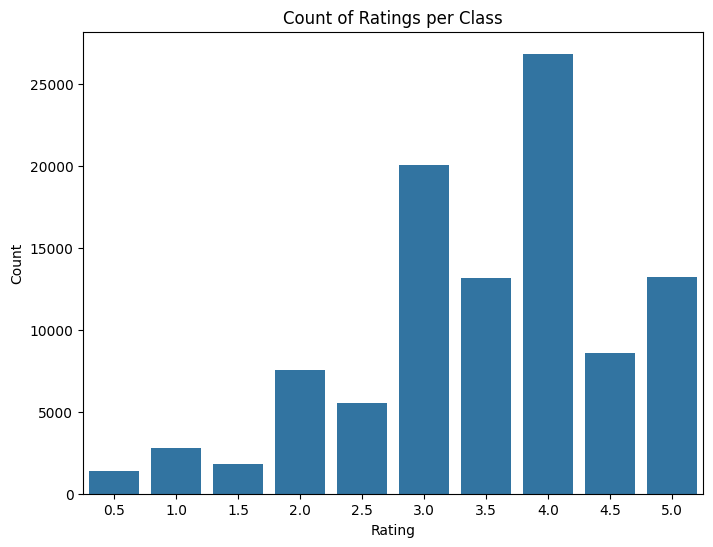

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create the count plot
plt.figure(figsize=(8, 6)) # Optional: Adjusts plot size
sns.countplot(x='rating', data=ratings)
plt.title('Count of Ratings per Class')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()


## Average rating

In [19]:
float(ratings["rating"].mean())

3.501556983616962

# 2. Sparsity Analysis

Sparsity refers to the high percentage of missing values in the user-item interaction matrix, where most users have only interacted with a tiny fraction of available items. It occurs when the number of items significantly exceeds user ratings, making it difficult to find similarities, leading to lower recommendation accuracy, poor coverage, and the "cold start" problem.

In [28]:
sparsity = 1 - (ratings["rating"].count())/ (ratings["userId"].nunique() * ratings["rating"].count())

print(f"Sparsity: {sparsity * 100:.2f}%")

Sparsity: 99.84%


# 3. Rating Distribution

A KDE (Kernel Density Estimate) plot is a method for visualizing the distribution of observations in a dataset, similar to a histogram but with a smooth, continuous curve.

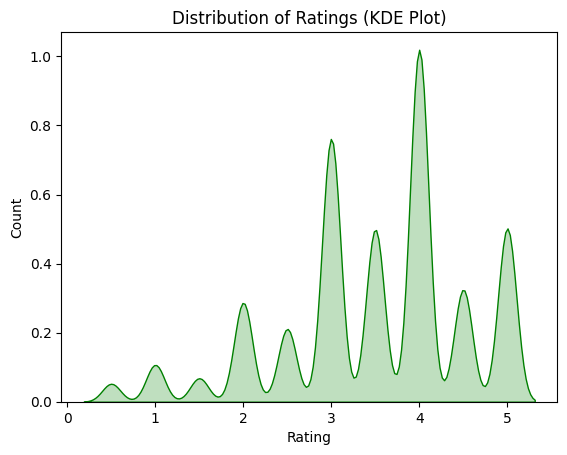

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot a KDE plot
sns.kdeplot(ratings["rating"], fill=True, color='green')
plt.title('Distribution of Ratings (KDE Plot)')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

# 4. User Activity Analysis

## Number of ratings per user

In [24]:
ratings_per_user = ratings.groupby('userId')['rating'].agg(['count'])
ratings_per_user

,count
userId,
1,232
2,29
3,39
4,216
5,44
...,...
606,1115
607,187
608,831


## Average rating given by each user

In [19]:
ratings.groupby("userId")["rating"].agg(["mean"])

,mean
userId,
1,4.366379
2,3.948276
3,2.435897
4,3.555556
5,3.636364
...,...
606,3.657399
607,3.786096
608,3.134176


## Super Users

Super users are users who have an extremely high number of interactions i.e ratings in our case.

Characteristics and impacts of super users include:

- **High Interaction Volume**: While most users might have a few interactions, super users have hundreds or thousands, making their data highly influential in collaborative filtering models.
- **Impact on Data Distribution**: They often create a long-tail distribution in the dataset, where a small percentage of users (the super users) account for a large percentage of the total interactions.
- **Noise and Bias**: In e-commerce, super users can represent "abnormal" traffic (e.g., automated bots or scraping tools), which adds noise to the data, reduces the effectiveness of recommendations, and biases split tests.
- **Handling in Datasets**: To prevent these users from dominating the model and causing over-fitting or recommending the same items to everyone, they are often filtered out or sampled differently during data preprocessing

In [51]:
mean_rating_count = int(ratings_per_user["count"].mean())
print("Mean Rating Count:", mean_rating_count)

# Find super users (counts >= mean)
super_user_idx = ratings_per_user[ratings_per_user["count"] >= mean_rating_count].index

print("Number of super users:", len(super_user_idx))

ratings[ratings["userId"].isin(super_user_idx)]

Mean Rating Count: 165
Number of super users: 159


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931
...,...,...,...,...
100831,610,166534,4.0,1493848402
100832,610,168248,5.0,1493850091
100833,610,168250,5.0,1494273047
100834,610,168252,5.0,1493846352


So there are 159 users in the dataset who have rated more movies than the global average of 165 and they have 72952 interactions combined!

# 5. Item Popularity & Long Tail

* Item popularity in recommender systems refers to the small set of widely consumed, "hit" items that receive most user attention.
* The long tail represents the vast majority of niche, obscure, or less-popular items.

Recommenders often bias toward popular items, leading to the "long tail problem" where unpopular items are ignored.

## Popular Movies

In [72]:
movie_rating_count = ratings.groupby("movieId")["rating"].agg(["count"])
movie_rating_count

,count
movieId,
1,215
2,110
3,52
4,7
5,49
...,...
193581,1
193583,1
193585,1


Keep in mind that we have 9724 unique movies in the dataset as computed in **dataset overview** section above.

In [120]:
mean_movie_rating_count = movie_rating_count["count"].mean()
print("Average number of ratings for each movie:", int(mean_movie_rating_count))

popular_movies = movie_rating_count[movie_rating_count["count"] >= int(mean_movie_rating_count)].index
print("Number of movies with rating count more than gloabl average:", len(popular_movies))

Average number of ratings for each movie: 10
Number of movies with rating count more than gloabl average: 2269


In [121]:
print("\nPopular movies with their ids and rating counts:")
movie_rating_count[movie_rating_count.index.isin(popular_movies)]


Popular movies with their ids and rating counts:


,count
movieId,
1,215
2,110
3,52
5,49
6,102
...,...
174055,13
176371,18
177765,13


In [95]:
print("Popular Movies:")

movies[movies["movieId"].isin(popular_movies)]

Popular Movies:


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
4,5,Father of the Bride Part II (1995),Comedy
5,6,Heat (1995),Action|Crime|Thriller
...,...,...,...
9571,174055,Dunkirk (2017),Action|Drama|Thriller|War
9604,176371,Blade Runner 2049 (2017),Sci-Fi
9621,177765,Coco (2017),Adventure|Animation|Children
9645,179819,Star Wars: The Last Jedi (2017),Action|Adventure|Fantasy|Sci-Fi


## The Long Tail

In [125]:
non_popular_movies = movie_rating_count[movie_rating_count["count"] < int(mean_movie_rating_count)]
print("Number of movies with rating count less than gloabl average:", len(non_popular_movies))

Number of movies with rating count less than gloabl average: 7455


In [206]:
item_popularity = ratings.groupby("movieId").size()
item_popularity = item_popularity.sort_values(ascending=False)

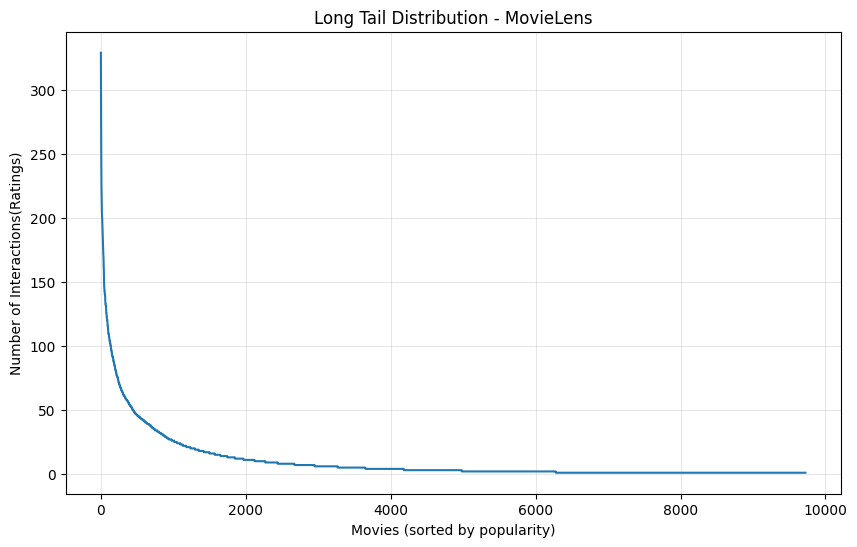

In [209]:
plt.figure(figsize=(10, 6))
plt.plot(range(len(item_popularity)), item_popularity.values)
plt.xlabel("Movies (sorted by popularity)")
plt.ylabel("Number of Interactions(Ratings)")
plt.title("Long Tail Distribution - MovieLens")
plt.grid(alpha=0.3)
plt.show()

In [208]:
non_popular_movies = movie_rating_count[~movie_rating_count.index.isin(popular_movies)]

print("Non-Popular Movies:")

movies[movies["movieId"].isin(non_popular_movies.index)]

Non-Popular Movies:


,movieId,title,genres
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
7,8,Tom and Huck (1995),Adventure|Children
12,13,Balto (1995),Adventure|Animation|Children
26,27,Now and Then (1995),Children|Drama
29,30,Shanghai Triad (Yao a yao yao dao waipo qiao) ...,Crime|Drama
...,...,...,...
9737,193581,Black Butler: Book of the Atlantic (2017),Action|Animation|Comedy|Fantasy
9738,193583,No Game No Life: Zero (2017),Animation|Comedy|Fantasy
9739,193585,Flint (2017),Drama
9740,193587,Bungo Stray Dogs: Dead Apple (2018),Action|Animation


# 6. Temporal Patterns

Temporal patterns in recommender systems refer to the time-varying, dynamic changes in user preferences, item popularity, or user-item interactions over time.

In [4]:
ratings_copy = ratings.copy()

ratings_copy["datetime"] = pd.to_datetime(ratings_copy["timestamp"], unit="s")

ratings_copy["year"] = ratings_copy["datetime"].dt.year
ratings_copy["month"] = ratings_copy["datetime"].dt.month
ratings_copy["day"] = ratings_copy["datetime"].dt.day
ratings_copy["day_of_week"] = ratings_copy["datetime"].dt.day_name()
ratings_copy["hour"] = ratings_copy["datetime"].dt.hour

ratings_copy.head()

,userId,movieId,rating,timestamp,datetime,year,month,day,day_of_week,hour
0,1,1,4.0,964982703,2000-07-30 18:45:03,2000,7,30,Sunday,18
1,1,3,4.0,964981247,2000-07-30 18:20:47,2000,7,30,Sunday,18
2,1,6,4.0,964982224,2000-07-30 18:37:04,2000,7,30,Sunday,18
3,1,47,5.0,964983815,2000-07-30 19:03:35,2000,7,30,Sunday,19
4,1,50,5.0,964982931,2000-07-30 18:48:51,2000,7,30,Sunday,18


Now we have structured time features.

## Ratings Over Time (Global Activity Trend)

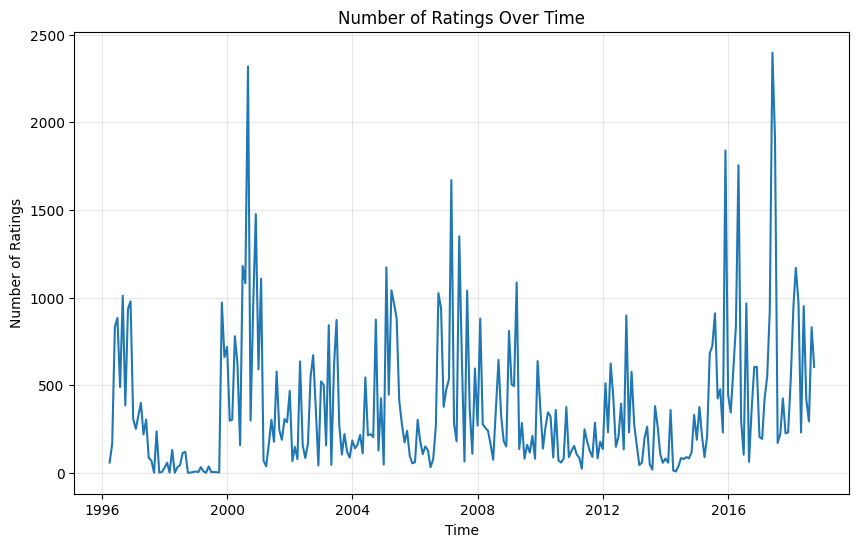

In [7]:
import matplotlib.pyplot as plt

ratings_per_month = ratings_copy.resample("ME", on="datetime").size()

plt.figure(figsize=(10,6))
plt.plot(ratings_per_month)
plt.title("Number of Ratings Over Time")
plt.xlabel("Time")
plt.ylabel("Number of Ratings")
plt.grid(alpha=0.3)
plt.show()

## Day of Week Pattern

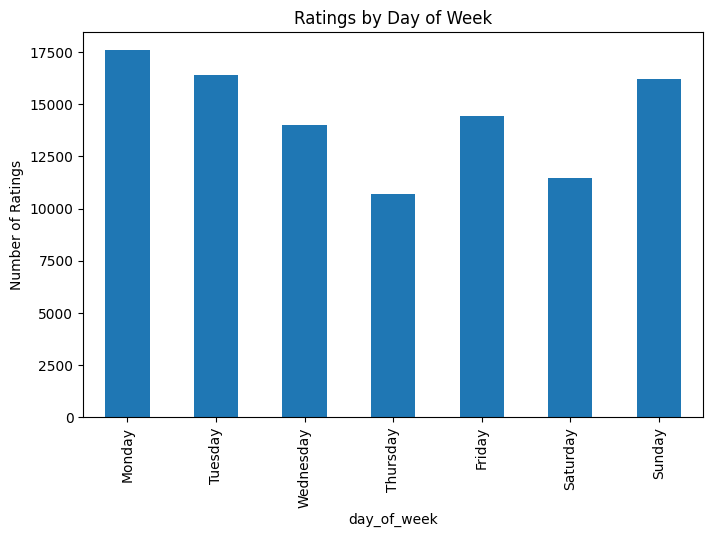

In [8]:
dow_counts = ratings_copy["day_of_week"].value_counts()

plt.figure(figsize=(8,5))
dow_counts.loc[
    ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
].plot(kind="bar")
plt.title("Ratings by Day of Week")
plt.ylabel("Number of Ratings")
plt.show()

## Hour-of-Day Activity

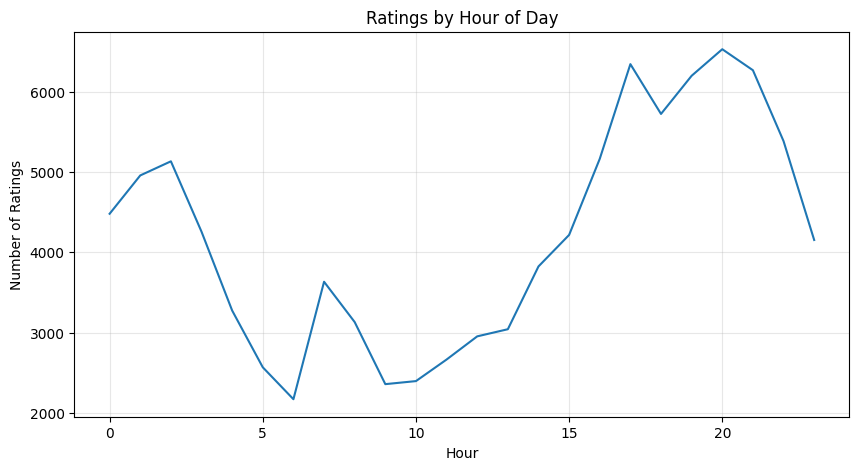

In [9]:
hour_counts = ratings_copy["hour"].value_counts().sort_index()

plt.figure(figsize=(10,5))
plt.plot(hour_counts)
plt.title("Ratings by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Number of Ratings")
plt.grid(alpha=0.3)
plt.show()

## Item Popularity Over Time (Dynamic Popularity)

Let’s see if some movies had bursts.

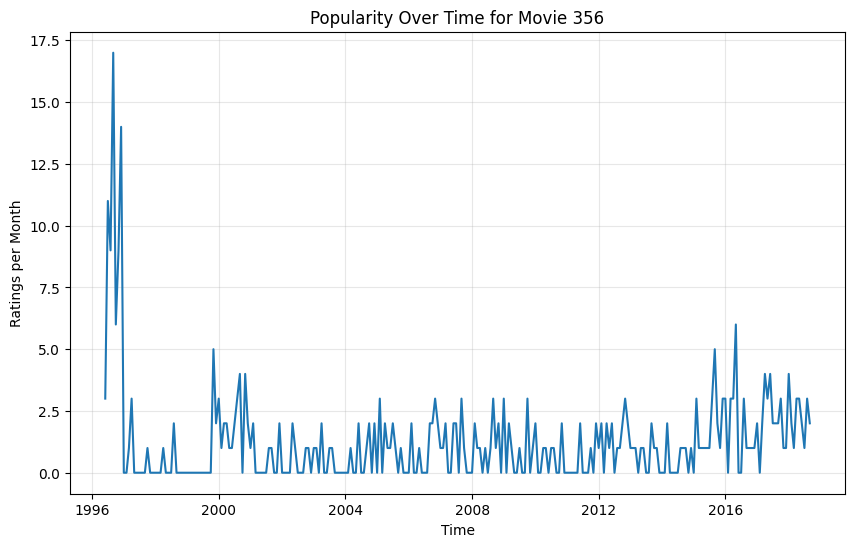

In [11]:
movie_id = ratings_copy["movieId"].value_counts().index[0]  # most popular movie

movie_trend = (
    ratings_copy[ratings_copy["movieId"] == movie_id]
    .resample("ME", on="datetime")
    .size()
)

plt.figure(figsize=(10,6))
plt.plot(movie_trend)
plt.title(f"Popularity Over Time for Movie {movie_id}")
plt.xlabel("Time")
plt.ylabel("Ratings per Month")
plt.grid(alpha=0.3)
plt.show()

The above plot reveals:

- Release bursts
- Seasonal spikes
- Long-term decay

## User Evolution Pattern

Are users consistent or bursty?

### One User

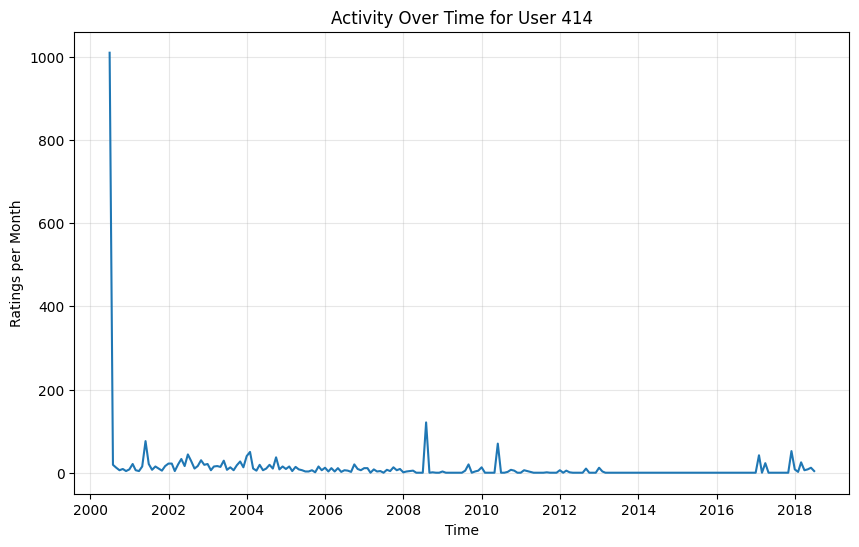

In [13]:
user_id = ratings_copy["userId"].value_counts().index[0]

user_activity = (
    ratings_copy[ratings_copy["userId"] == user_id]
    .resample("ME", on="datetime")
    .size()
)

plt.figure(figsize=(10,6))
plt.plot(user_activity)
plt.title(f"Activity Over Time for User {user_id}")
plt.xlabel("Time")
plt.ylabel("Ratings per Month")
plt.grid(alpha=0.3)
plt.show()

### Another User

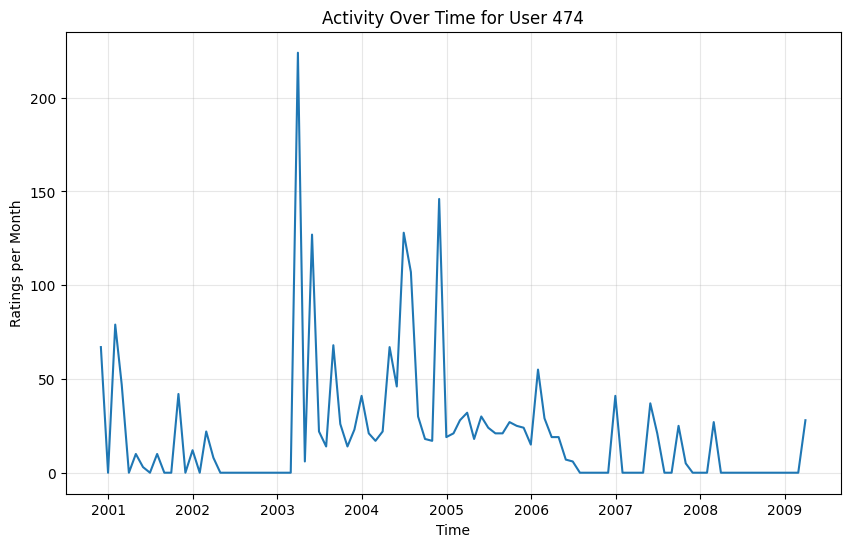

In [16]:
user_id = ratings_copy["userId"].value_counts().index[2]

user_activity = (
    ratings_copy[ratings_copy["userId"] == user_id]
    .resample("ME", on="datetime")
    .size()
)

plt.figure(figsize=(10,6))
plt.plot(user_activity)
plt.title(f"Activity Over Time for User {user_id}")
plt.xlabel("Time")
plt.ylabel("Ratings per Month")
plt.grid(alpha=0.3)
plt.show()

The above plots reveal:

- Short bursts of high activity
- Long inactive periods

## Rating Drift

Do average ratings change over time?

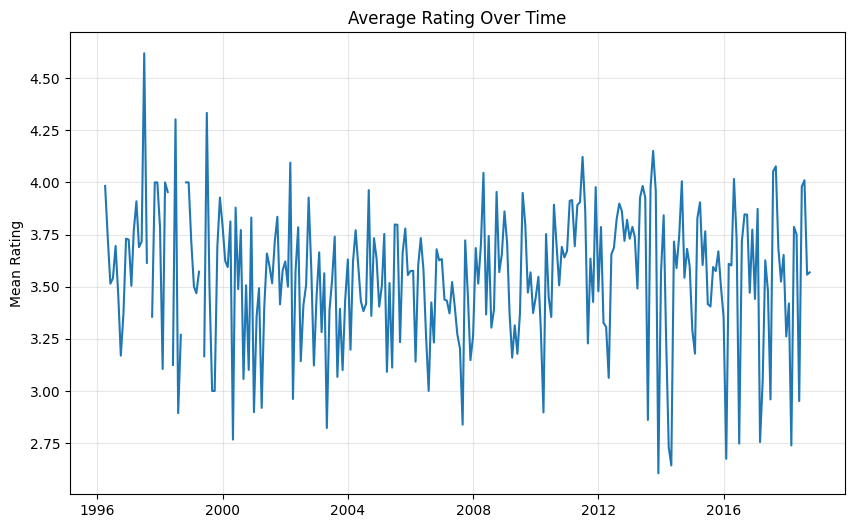

In [14]:
avg_rating_over_time = ratings_copy.resample("ME", on="datetime")["rating"].mean()

plt.figure(figsize=(10,6))
plt.plot(avg_rating_over_time)
plt.title("Average Rating Over Time")
plt.ylabel("Mean Rating")
plt.grid(alpha=0.3)
plt.show()

# 7. Cold Start Analysis

The "cold start" refers to a state where the recommendation engine's "engine" is too cold to start, often compared to needing to "warm up" with interaction data before providing good recommendations.

Types of Cold Start Problems:

- New User Cold Start: A new user registers, but the system has zero historical data about their preferences, making it impossible to recommend personalized items.
- New Item Cold Start: A new product is added to the catalog. Since no users have bought or rated it, the system cannot recommend it based on user behavior.
- System Cold Start: A new platform is launched where no user data exists at all.

## User Cold Start Analysis

In [30]:
user_cold_threshold = 50

In [31]:
user_activity = ratings.groupby("userId").size()

cold_users = user_activity[user_activity <= user_cold_threshold]
warm_users = user_activity[user_activity > user_cold_threshold]

print("Total users:", len(user_activity))
print("Cold users:", len(cold_users))
print("Cold user %:", len(cold_users) / len(user_activity) * 100)

Total users: 610
Cold users: 232
Cold user %: 38.0327868852459


## Item Cold Start Analysis

In [37]:
item_cold_threshold = 5

In [45]:
item_popularity = ratings.groupby("movieId").size()

cold_items = item_popularity[item_popularity <= item_cold_threshold]
warm_items = item_popularity[item_popularity > item_cold_threshold]

print("Total items:", len(item_popularity))
print("Cold items:", len(cold_items))
print("Cold item %:", len(cold_items) / len(item_popularity) * 100)

Total items: 9724
Cold items: 6456
Cold item %: 66.39243109831345


## Cold Ratio

This tells us how much of the dataset is affected by cold items.

The formula is:

$Cold\ Ratio=\frac{Interactions \ from\ cold\ entities​}{Total\ Interactions}$

In [46]:
cold_item_ids = cold_items.index
cold_interactions = ratings[ratings["movieId"].isin(cold_item_ids)]

print("Cold interaction ratio:", len(cold_interactions) / len(ratings))

Cold interaction ratio: 0.12368598516402872
